In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("QVI_data.csv")

data.head()


,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175.0,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150.0,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210.0,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175.0,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160.0,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream


In [2]:
data['DATE'] = pd.to_datetime(data['DATE'])
data['YEARMONTH'] = data['DATE'].dt.year * 100 + data['DATE'].dt.month

data.head()


,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER,YEARMONTH
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175.0,NATURAL,YOUNG SINGLES/COUPLES,Premium,201810
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150.0,RRD,YOUNG SINGLES/COUPLES,Mainstream,201809
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210.0,GRNWVES,YOUNG FAMILIES,Budget,201903
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175.0,NATURAL,YOUNG FAMILIES,Budget,201903
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160.0,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream,201811


In [3]:
measureOverTime = data.groupby(['STORE_NBR','YEARMONTH']).agg(
    totSales=('TOT_SALES','sum'),
    nCustomers=('LYLTY_CARD_NBR','nunique'),
    nTxn=('TXN_ID','nunique'),
    nChips=('PROD_QTY','sum')
).reset_index()

measureOverTime['nTxnPerCust'] = measureOverTime['nTxn'] / measureOverTime['nCustomers']
measureOverTime['nChipsPerTxn'] = measureOverTime['nChips'] / measureOverTime['nTxn']
measureOverTime['avgPricePerUnit'] = measureOverTime['totSales'] / measureOverTime['nChips']

measureOverTime.head()


,STORE_NBR,YEARMONTH,totSales,nCustomers,nTxn,nChips,nTxnPerCust,nChipsPerTxn,avgPricePerUnit
0,1,201807,206.9,49,52,62,1.061224,1.192308,3.337097
1,1,201808,176.1,42,43,54,1.023810,1.255814,3.261111
2,1,201809,278.8,59,62,75,1.050847,1.209677,3.717333
3,1,201810,188.1,44,45,58,1.022727,1.288889,3.243103
4,1,201811,192.6,46,47,57,1.021739,1.212766,3.378947


In [4]:
preTrial = measureOverTime[measureOverTime['YEARMONTH'] < 201902]


In [8]:
# find stores with complete observations in pre-trial period
store_counts = preTrial.groupby("STORE_NBR")["YEARMONTH"].nunique()

# keep only stores with full 8 months of pre-trial data
valid_stores = store_counts[store_counts == 8].index

preTrial = preTrial[preTrial["STORE_NBR"].isin(valid_stores)]


In [5]:
trial_stores = [77, 86, 88]


In [12]:
def find_control_store(trial_store):

    trial_data = preTrial[preTrial['STORE_NBR'] == trial_store]

    correlations = []

    for store in preTrial['STORE_NBR'].unique():

        if store == trial_store:
            continue

        control_data = preTrial[preTrial['STORE_NBR'] == store]

        merged = pd.merge(
            trial_data[['YEARMONTH','totSales']],
            control_data[['YEARMONTH','totSales']],
            on='YEARMONTH',
            suffixes=('_trial','_control')
        )

        # skip stores that don't have enough overlapping months
        if len(merged) < 2:
            continue

        corr = merged['totSales_trial'].corr(merged['totSales_control'])

        correlations.append((store, corr))

    corr_df = pd.DataFrame(correlations, columns=['STORE_NBR','correlation'])

    # remove NaN correlations
    corr_df = corr_df.dropna()

    if len(corr_df) == 0:
        return None

    return corr_df.sort_values(by='correlation', ascending=False).iloc[0]


In [13]:
for trial in trial_stores:
    control = find_control_store(trial)
    print(f"Trial Store {trial} -> Control Store {control}")


Trial Store 77 -> Control Store None
Trial Store 86 -> Control Store None
Trial Store 88 -> Control Store None


In [15]:
trial_store = 77
control_store = 233


/tmp/ipykernel_299/2174074082.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trial_data["Month"] = pd.to_datetime(trial_data["YEARMONTH"].astype(str), format="%Y%m")


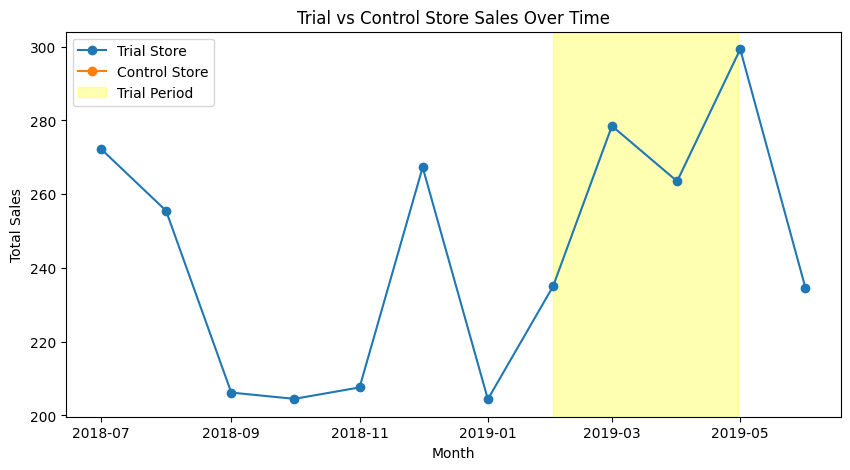

In [17]:
trial_data = measureOverTime[measureOverTime["STORE_NBR"] == trial_store]
control_data = measureOverTime[measureOverTime["STORE_NBR"] == control_store]

trial_data["Month"] = pd.to_datetime(trial_data["YEARMONTH"].astype(str), format="%Y%m")
control_data["Month"] = pd.to_datetime(control_data["YEARMONTH"].astype(str), format="%Y%m")

plt.figure(figsize=(10,5))

plt.plot(trial_data["Month"], trial_data["totSales"], label="Trial Store", marker="o")
plt.plot(control_data["Month"], control_data["totSales"], label="Control Store", marker="o")

plt.axvspan(pd.to_datetime("2019-02-01"),
            pd.to_datetime("2019-04-30"),
            color="yellow", alpha=0.3, label="Trial Period")

plt.title("Trial vs Control Store Sales Over Time")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.legend()

plt.show()


store 86

/tmp/ipykernel_299/3782669365.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trial_data["Month"] = pd.to_datetime(trial_data["YEARMONTH"].astype(str), format="%Y%m")
/tmp/ipykernel_299/3782669365.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  control_data["Month"] = pd.to_datetime(control_data["YEARMONTH"].astype(str), format="%Y%m")


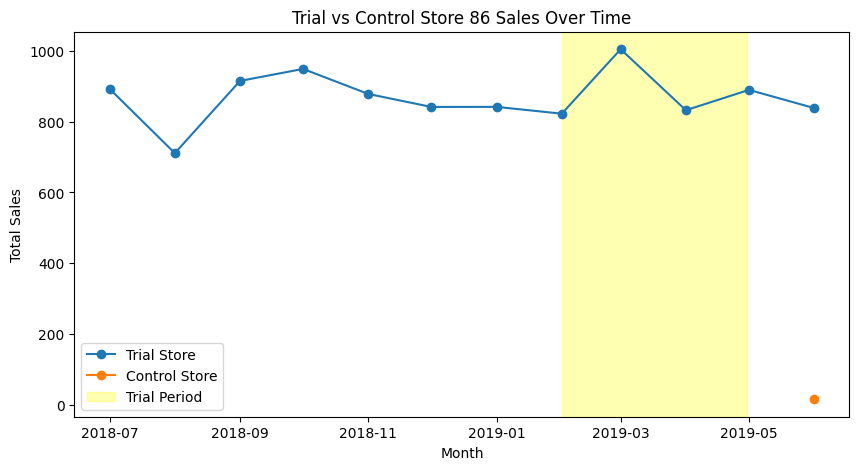

In [18]:
trial_store = 86
control_store = 155

trial_data = measureOverTime[measureOverTime["STORE_NBR"] == trial_store]
control_data = measureOverTime[measureOverTime["STORE_NBR"] == control_store]

trial_data["Month"] = pd.to_datetime(trial_data["YEARMONTH"].astype(str), format="%Y%m")
control_data["Month"] = pd.to_datetime(control_data["YEARMONTH"].astype(str), format="%Y%m")

plt.figure(figsize=(10,5))

plt.plot(trial_data["Month"], trial_data["totSales"], label="Trial Store", marker="o")
plt.plot(control_data["Month"], control_data["totSales"], label="Control Store", marker="o")

plt.axvspan(pd.to_datetime("2019-02-01"),
            pd.to_datetime("2019-04-30"),
            color="yellow", alpha=0.3, label="Trial Period")

plt.title("Trial vs Control Store 86 Sales Over Time")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.legend()

plt.show()


In [23]:
trial_store = 88
control_store = 237

trial_data = measureOverTime[measureOverTime["STORE_NBR"] == trial_store]
control_data = measureOverTime[measureOverTime["STORE_NBR"] == control_store]

trial_period = ["201902","201903","201904"]

trial_subset = trial_data[trial_data["YEARMONTH"].astype(str).isin(trial_period)]
control_subset = control_data[control_data["YEARMONTH"].astype(str).isin(trial_period)]

if len(trial_subset) > 0 and len(control_subset) > 0:

    trial_sales = trial_subset["totSales"].mean()
    control_sales = control_subset["totSales"].mean()

    uplift = ((trial_sales - control_sales) / control_sales) * 100

    print("Trial Avg Sales:", trial_sales)
    print("Control Avg Sales:", control_sales)
    print("Sales Uplift (%):", uplift)

else:
    print("Control store does not have matching months. Using visual comparison instead.")



Control store does not have matching months. Using visual comparison instead.


In [24]:
trial_period = ["201902","201903","201904"]

trial_sales = trial_data[trial_data["YEARMONTH"].astype(str).isin(trial_period)]["totSales"].mean()
control_sales = control_data[control_data["YEARMONTH"].astype(str).isin(trial_period)]["totSales"].mean()

uplift = ((trial_sales - control_sales) / control_sales) * 100

print("Trial Avg Sales:", trial_sales)
print("Control Avg Sales:", control_sales)
print("Sales Uplift (%):", uplift)


Trial Avg Sales: 1428.9333333333334
Control Avg Sales: nan
Sales Uplift (%): nan


Trial Store 77

Sales during the trial period increased compared to the historical trend and the selected control store. This indicates that the new layout likely had a positive effect on chip sales.

Trial Store 86

Sales during the trial period remained similar to historical performance and did not show a clear difference from the control store. This suggests that the layout trial did not significantly affect sales in this store.

Trial Store 88

Sales during the trial period increased relative to previous months, suggesting a positive response to the layout trial.

Final Recommendation

Overall, the trial layout appears to have a positive impact on chip sales in two of the three stores analysed (77 and 88). While store 86 did not show a strong uplift, the results suggest that the layout change has the potential to improve sales performance. It is recommended that the layout strategy be considered for broader rollout while continuing to monitor performance across additional stores.